In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from pydantic import BaseModel
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from typing import Annotated

In [4]:
class ChatState(BaseModel):
    messages: Annotated[list, add_messages]

In [6]:
llm = ChatGroq(model="openai/gpt-oss-20b")

In [7]:
def chatBotNode(state: ChatState) -> ChatState:
    res = llm.invoke(state.messages)
    state.messages = [res]
    return state


In [9]:
memory = InMemorySaver()

In [8]:
graph = StateGraph(ChatState)
graph.add_node("chatBot", chatBotNode)

graph.add_edge(START, "chatBot")
graph.add_edge("chatBot", END)

In [11]:
graph = graph.compile(checkpointer=memory)

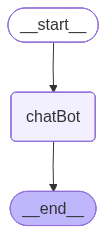

In [12]:
graph

In [20]:
res = graph.invoke(
    {"messages":[{"role":"user", "content":"what is my name?"}]},
    {"configurable":{"thread_id":"my-bot-1"}}
    )

In [21]:
res["messages"][-1].content

'Your name is Akash\u202fYadav.'